### Libraries

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

### EDA Sensor Data

In [4]:
# Load all Sensor files
folder = Path("../data")
files = list(folder.glob("data-*.csv"))

column_names = [
    "sensor_id",
    "direction",
    "vehicle_type",
    "start_time",
    "end_time",
    "count"
]

dfs = []
for file in files:
    df= pd.read_csv(file, header=None, names=column_names)
    dfs.append(df)
    print(f"Loaded: {file.name} - {len(df):,} rows")

bike_data = pd.concat(dfs, ignore_index=True)
print(f"Total files: {len(files)}")
print(f"Total rows: {len(bike_data):,}")


Loaded: data-2019-08.csv - 123,148 rows
Loaded: data-2019-09.csv - 138,240 rows
Loaded: data-2019-10.csv - 142,848 rows
Loaded: data-2019-11.csv - 138,240 rows
Loaded: data-2019-12.csv - 142,848 rows
Loaded: data-2020-01.csv - 142,848 rows
Loaded: data-2020-02.csv - 133,632 rows
Loaded: data-2020-03.csv - 142,656 rows
Loaded: data-2020-04.csv - 144,000 rows
Loaded: data-2020-05.csv - 148,800 rows
Loaded: data-2020-06.csv - 144,000 rows
Loaded: data-2020-07.csv - 148,800 rows
Loaded: data-2020-08.csv - 148,800 rows
Loaded: data-2020-09.csv - 144,000 rows
Loaded: data-2020-10.csv - 148,800 rows
Loaded: data-2020-11.csv - 144,000 rows
Loaded: data-2020-12.csv - 148,800 rows
Loaded: data-2021-01.csv - 148,800 rows
Loaded: data-2021-02.csv - 134,400 rows
Loaded: data-2021-03.csv - 148,600 rows
Loaded: data-2021-04.csv - 144,000 rows
Loaded: data-2021-05.csv - 148,800 rows
Loaded: data-2021-06.csv - 144,000 rows
Loaded: data-2021-07.csv - 156,864 rows
Loaded: data-2021-08.csv - 160,704 rows


In [5]:
#Column types
bike_data.dtypes

sensor_id         int64
direction        object
vehicle_type     object
start_time       object
end_time         object
count           float64
dtype: object

In [6]:
#First rows
bike_data.head()

,sensor_id,direction,vehicle_type,start_time,end_time,count
0,1,IN,FIETSERS,2019-08-01 00:00:00.0,2019-08-01 00:15:00.0,0.0
1,1,IN,FIETSERS,2019-08-01 00:15:00.0,2019-08-01 00:30:00.0,0.0
2,1,IN,FIETSERS,2019-08-01 00:30:00.0,2019-08-01 00:45:00.0,0.0
3,1,IN,FIETSERS,2019-08-01 00:45:00.0,2019-08-01 01:00:00.0,0.0
4,1,IN,FIETSERS,2019-08-01 01:00:00.0,2019-08-01 01:15:00.0,1.0


In [7]:
# Time range
bike_data["start_time"] = pd.to_datetime(bike_data["start_time"])
print(f"From: {bike_data["start_time"].min()}")
print(f"To: {bike_data["start_time"].max()}")
print(f"Months: {bike_data["start_time"].dt.to_period('M').nunique()}")

From: 2019-08-01 00:00:00
To: 2026-03-19 03:15:00
Months: 80


In [8]:
#Variable analysis
print(f"Unique sensors: {bike_data['sensor_id'].nunique()}")
print(bike_data["vehicle_type"].value_counts())
print(bike_data["direction"].value_counts())
print(bike_data["count"].describe())


Unique sensors: 150
vehicle_type
FIETSERS       41458044
VOETGANGERS       23048
Name: count, dtype: int64
direction
IN     20740546
OUT    20740546
Name: count, dtype: int64
count    4.041012e+07
mean     2.571638e+00
std      7.069346e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.000000e+00
max      5.402000e+03
Name: count, dtype: float64


Most of the data are cyclist, in and out is balanced, count distribution is interesting

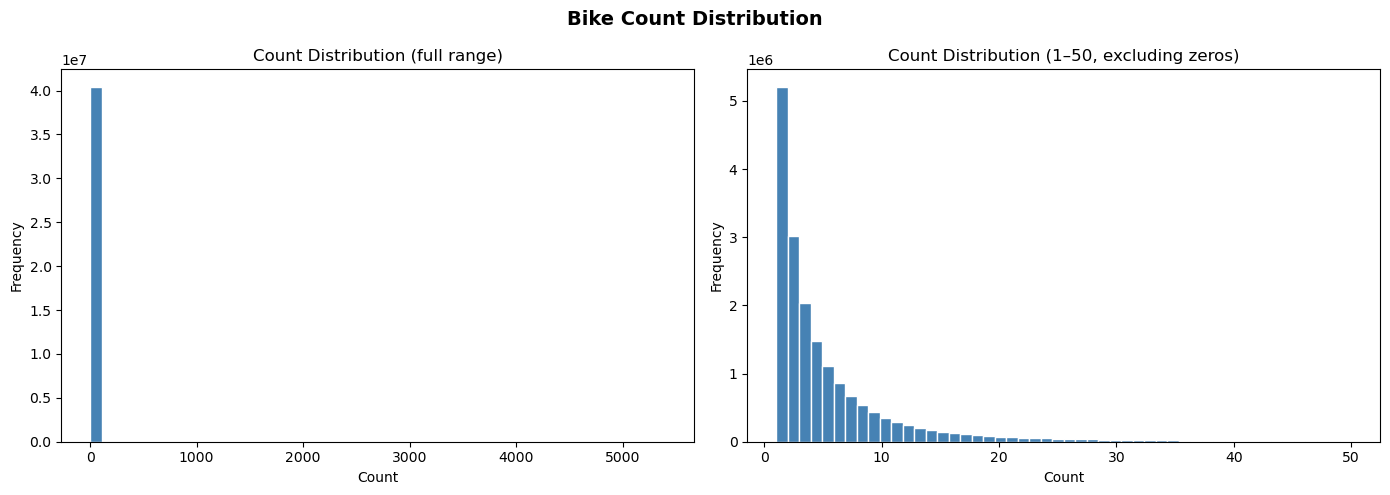

In [9]:
#Visual exploration of count distibution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left graph: full disribution
axes[0].hist(bike_data["count"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Count Distribution (full range)")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Frequency")

# Right graph: zoomed distribution (between 1 and 50)
zoomed = bike_data[(bike_data["count"] > 0) & (bike_data["count"] <= 50)]["count"]
axes[1].hist(zoomed, bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Count Distribution (1–50, excluding zeros)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Frequency")

plt.suptitle("Bike Count Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Majority of 15 minutes intervals have 0 cyclists <br>
Right-skewed <br>
Max of 5.402 sugget outliers <br>

In [10]:
#Nulls detection
bike_data.isnull().sum()

sensor_id             0
direction             0
vehicle_type          0
start_time            0
end_time              0
count           1070969
dtype: int64

In [23]:
#Nulls exploration
total=len(bike_data)
nulls = bike_data["count"].isnull().sum()
print(f"Null count: {nulls:,} ({nulls/total*100:.2f}%)")

total_by_sensor = bike_data.groupby("sensor_id")["count"].size()
nulls_by_sensor = bike_data.groupby("sensor_id")["count"].apply(lambda x: x.isnull().sum())

null_summary = pd.DataFrame({
    "total_count": total_by_sensor,
    "null_count": nulls_by_sensor,
    "null_pct": (nulls_by_sensor / total_by_sensor * 100).round(2)
}).sort_values("null_pct", ascending=False)

#Nulls by sensor
#table 1 : null rate by sensor
print("Sensors with highest null rate:")
table1 = null_summary[null_summary["null_count"] > 0][
    ["total_count", "null_count", "null_pct"]
].sort_values("null_pct", ascending=False)
print(table1.head(15))

# table 2 contribution to total null by sensor
print("\nSensors contributing most to total nulls:")
table2 = null_summary[null_summary["null_count"] > 0][
    ["total_count", "null_count", "null_pct"]
].sort_values("null_count", ascending=False)

table2["cumulative_null_pct"] = (
    table2["null_count"].cumsum() /
    table2["null_count"].sum() * 100
).round(2)

print(table2.head(10))

Null count: 1,070,969 (2.58%)
Sensors with highest null rate:
           total_count  null_count  null_pct
sensor_id                                   
144               5762        5762    100.00
123             110230       84692     76.83
152              32416        5762     17.78
150              35130        5662     16.12
151              34746        5446     15.67
143             184328       23344     12.66
95              213754       27044     12.65
149              44538        5460     12.26
148              45498        5466     12.01
147              45690        5468     11.97
119             242130       28232     11.66
124             235270       27308     11.61
80              224094       25042     11.17
142               8834         962     10.89
73              270908       27586     10.18

Sensors contributing most to total nulls:
           total_count  null_count  null_pct  cumulative_null_pct
sensor_id                                                       

Sensor 144 & Sensor 123 have high % of null counts <br>
Other sensors have low null rates (<12%) -> drop nulls in preprocessing

In [13]:
#Explore Sensors 144 & 123
print("Sensor 144:")
print(bike_data[bike_data["sensor_id"] == 144]["start_time"].min())
print(bike_data[bike_data["sensor_id"] == 144]["start_time"].max())
print(f"Total rows: {len(bike_data[bike_data['sensor_id'] == 144]):,}")

print("\nSensor 123:")
print(bike_data[bike_data["sensor_id"] == 123]["start_time"].min())
print(bike_data[bike_data["sensor_id"] == 123]["start_time"].max())
print(f"Total rows: {len(bike_data[bike_data['sensor_id'] == 123]):,}")

Sensor 144:
2023-12-12 08:15:00
2024-01-11 08:15:00
Total rows: 5,762

Sensor 123:
2022-09-06 02:00:00
2026-03-18 03:45:00
Total rows: 110,230


Sensor 144 just one month of data and all null -> eliminate in preprocessing <br>
Sensor 123 info from september 2022, but just 25,526 and  nulls -> candidate to eliminate or work with care

In [14]:
# Are nulls concentrated in specific years?
bike_data["year"] = bike_data["start_time"].dt.year

total_by_year = bike_data.groupby("year")["count"].size()
nulls_by_year = bike_data[bike_data["count"].isnull()].groupby("year")["count"].size()

year_summary = pd.DataFrame({
    "total_count": total_by_year,
    "null_count": nulls_by_year,
    "null_pct": (nulls_by_year / total_by_year * 100).round(2)
}).fillna(0)

print(year_summary)

      total_count  null_count  null_pct
year                                   
2019       685324        3268      0.48
2020      1739136        9653      0.56
2021      1818616       24927      1.37
2022      5918634      570890      9.65
2023      9589592       69560      0.73
2024      9684132      104809      1.08
2025      9908890      244938      2.47
2026      2136768       42924      2.01


In [15]:
# Which months in 2022 have the most nulls?
bike_data["month"] = bike_data["start_time"].dt.month

nulls_2022_by_month = bike_data[
    (bike_data["count"].isnull()) &
    (bike_data["year"] == 2022)
].groupby("month")["count"].size()

total_2022_by_month = bike_data[
    bike_data["year"] == 2022
].groupby("month")["count"].size()

month_2022_summary = pd.DataFrame({
    "total_count": total_2022_by_month,
    "null_count": nulls_2022_by_month,
    "null_pct": (nulls_2022_by_month / total_2022_by_month * 100).round(2)
}).fillna(0)

print(month_2022_summary)

       total_count  null_count  null_pct
month                                   
1           160704      1980.0      1.23
2           145152         0.0      0.00
3           203704     43230.0     21.22
4           267250     63154.0     23.63
5           368518     90142.0     24.46
6           486830    124142.0     25.50
7           632122    117048.0     18.52
8           668966     34446.0      5.15
9           714104     65592.0      9.19
10          767808     29656.0      3.86
11          740358         6.0      0.00
12          763118      1494.0      0.20


Between march and july of 2022 there were problems

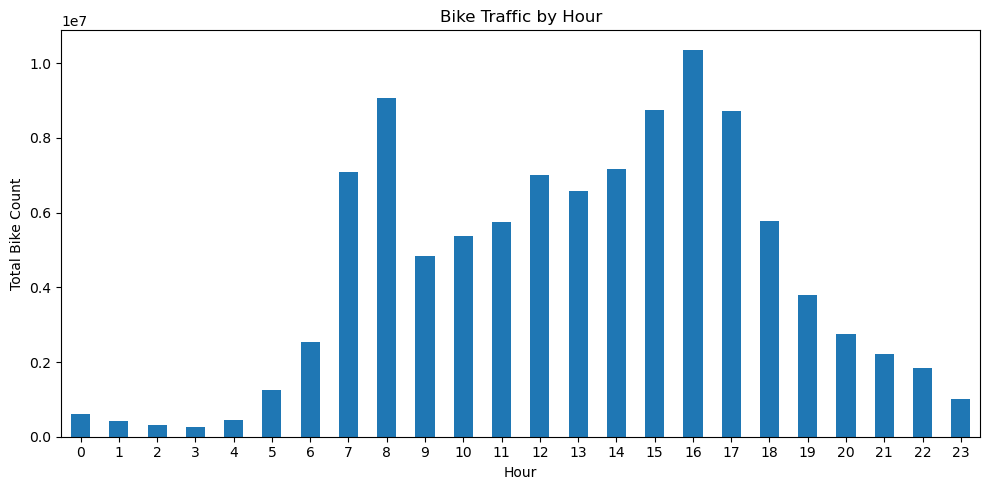

In [16]:
#Traffic by hour
bike_data["hour"] = bike_data["start_time"].dt.hour
hourly_traffic = bike_data.groupby("hour")["count"].sum()
plt.figure(figsize=(10, 5))
hourly_traffic.plot(kind="bar")
plt.title("Bike Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Total Bike Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

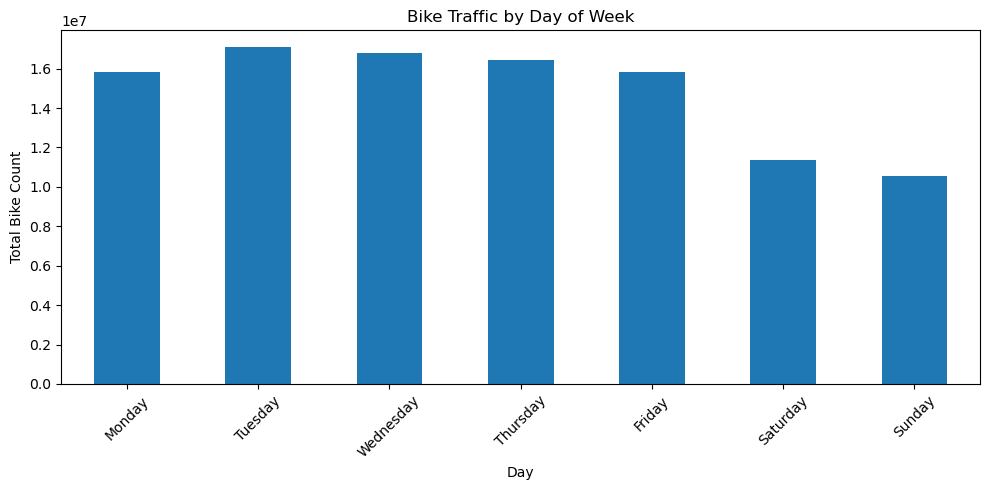

In [17]:
#Traffic by day of the week
bike_data["day_of_week"] = bike_data["start_time"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_traffic = bike_data.groupby("day_of_week")["count"].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
daily_traffic.plot(kind="bar")
plt.title("Bike Traffic by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Bike Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

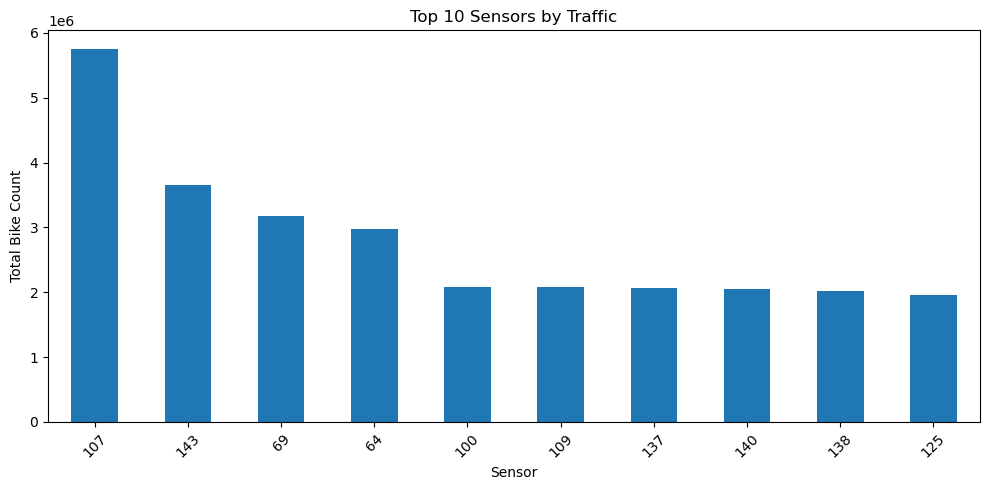

In [18]:
#Top 10 sensors by traffic
top_sensors = bike_data.groupby("sensor_id")["count"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
top_sensors.head(10).plot(kind="bar")
plt.title("Top 10 Sensors by Traffic")
plt.xlabel("Sensor")
plt.ylabel("Total Bike Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Load Sites Data

In [21]:
site_columns = [
    "sensor_id", "site_nr", "longitude", "latitude", "name",
    "domain", "road_number", "district", "municipality", "interval", "installation_date"
]

sites = pd.read_csv("../data/sites.csv", header=None, names=site_columns)
print(f"Sites shape: {sites.shape}")
print(sites.head())
#Check null values

print(f"Null values:")
print(sites.isnull().sum())
#Check duplicate values
duplicated_sites = sites[sites.duplicated(subset=["sensor_id"], keep=False)]
print(f"Duplicated rows: {len(duplicated_sites)}")

#Check sites coordinates duplicates
duplicated_sites = sites[sites.duplicated(subset=["longitude","latitude"], keep=False)]
print(f"Duplicated sites: {len(duplicated_sites)}")


Sites shape: (151, 11)
   sensor_id    site_nr  longitude   latitude          name  \
0          1  100046096   4.456122  50.916183      Machelen   
1          2  100052862   4.471690  51.275120  Brasschaat 2   
2          3  100052863   4.472220  51.275030  Brasschaat 1   
3          4  100052864   5.190110  51.160230       Balen 1   
4          5  100052865   5.190030  51.160180       Balen 2   

                                domain road_number district municipality  \
0  Vlaamse Overheid A. Wegen enVerkeer    T2110002   AWV212     Machelen   
1  Vlaamse Overheid A. Wegen enVerkeer    N0010002   AWV123   Brasschaat   
2  Vlaamse Overheid A. Wegen enVerkeer    N0010001   AWV123   Brasschaat   
3  Vlaamse Overheid A. Wegen enVerkeer    N0180002   AWV114        Balen   
4  Vlaamse Overheid A. Wegen enVerkeer    N0180002   AWV114        Balen   

   interval installation_date  
0        15        2019-08-22  
1        15        2019-08-22  
2        15        2019-08-22  
3        15  

Few null values <br>
3 road_number <br>
3 district <br>
1 municipality <br>
No duplicated rows <br>
4 duplicated sites coordinates

In [22]:
#Explore duplicated coordinates
duplicated_sites.head()


,sensor_id,site_nr,longitude,latitude,name,domain,road_number,district,municipality,interval,installation_date
51,52,300024459,3.24095,51.226320,Brugge,Vlaamse Overheid A. Wegen enVerkeer,N3740002,AWV311,Brugge,15,2022-06-01
115,116,300027878,3.80406,50.998611,Melle teller 2,Vlaamse Overheid A. Wegen enVerkeer,N4650001,AWV411,Melle,15,2022-10-01
116,117,300027879,3.80406,50.998611,Melle teller 1,Vlaamse Overheid A. Wegen enVerkeer,N4650001,AWV411,Melle,15,2022-10-01
140,142,300036881,3.24095,51.226320,TEST Validatie BRUGGE Y2H22022134,Vlaamse Overheid A. Wegen enVerkeer,N3740002,AWV311,Brugge,15,2023-10-24


Sensor 142 appears to be a test sensor, it also had 10.89% of null values, we should taking it out of the sample <br>
Sensors 116 & 117 are in the same locations but they have different names so they probably capture different information

#### Load Richtingen Data

In [24]:
direction_columns = ["sensor_id", "direction", "direction_name"]

directions = pd.read_csv("../data/richtingen.csv", header=None, names=direction_columns)
print(f"Directions shape: {directions.shape}")
print(directions.head())
#Check null values
print(directions.isnull().sum())

#Check duplicated values
duplicated_directions = directions[directions.duplicated(subset=["sensor_id","direction"], keep=False)]
print(f"Duplicated rows: {len(duplicated_directions)}")

Directions shape: (305, 3)
   sensor_id direction                         direction_name
0          1        IN       Machelen Cyclists rich. Brucargo
1          1       OUT    Machelen Cyclists richting Machelen
2          2        IN     Brasschaat 2 Fietsers rich Merksem
3          2       OUT  Brasschaat 2 Fietsers rich Brasschaat
4          3        IN     Brasschaat 1 Fietsers rich Merksem
sensor_id         0
direction         0
direction_name    0
dtype: int64
Duplicated rows: 0


No null values, no duplicates

In [25]:
#Consistency check between sites and directions
bike_sensors = set(bike_data["sensor_id"].unique())
site_sensors = set(sites["sensor_id"].unique())
direction_sensors = set(directions["sensor_id"].unique())

print(f"Sensors in bike_data: {len(bike_sensors)}")
print(f"Sensors in sites: {len(site_sensors)}")
print(f"Sensors in directions: {len(direction_sensors)}")

missing_in_sites = sorted([int(x) for x in bike_sensors - site_sensors])
missing_in_bike = sorted([int(x) for x in site_sensors - bike_sensors])
missing_in_directions = sorted([int(x) for x in bike_sensors - direction_sensors])

print(f"\nIn bike_data but not in sites: {missing_in_sites if missing_in_sites else 'None'}")
print(f"In sites but not in bike_data: {missing_in_bike if missing_in_bike else 'None'}")
print(f"In bike_data but not in directions: {missing_in_directions if missing_in_directions else 'None'}")

Sensors in bike_data: 150
Sensors in sites: 151
Sensors in directions: 151

In bike_data but not in sites: None
In sites but not in bike_data: [141]
In bike_data but not in directions: None


Sensor 141 is not in bike_data, but every sensor is in sites and direction data

#### Accidents data

In [26]:
accidents = pd.read_excel("../data/OPENDATA_MAP_2017-2024.xlsx")
print(f"Accidents shape: {accidents.shape}")
print(accidents.head())
print(accidents.isnull().sum())


Accidents shape: (289532, 45)
   DT_YEAR_COLLISION  DT_MONTH_COLLISION  DT_TIME  CD_NIS  \
0               2017                   1        1   21015   
1               2017                   1        0   11002   
2               2017                   1        1   71016   
3               2017                   1       10   21001   
4               2017                   1        7   11035   

            TX_RGN_COLLISION_FR             TX_RGN_COLLISION_NL  \
0  Région de Bruxelles-Capitale  Brussels Hoofdstedelijk Gewest   
1               Région flamande                   Vlaams Gewest   
2               Région flamande                   Vlaams Gewest   
3  Région de Bruxelles-Capitale  Brussels Hoofdstedelijk Gewest   
4               Région flamande                   Vlaams Gewest   

   TX_PROV_COLLISION_FR TX_PROV_COLLISION_NL TX_MUNTY_COLLISION_FR  \
0                   NaN                  NaN            Schaerbeek   
1     Province d’Anvers  Provincie Antwerpen                

In [27]:
#Filter just bikes and just Flanders
accidents_flanders = accidents[
    accidents["TX_RGN_COLLISION_NL"] == "Vlaams Gewest"]

accidents_bikes = accidents_flanders[
    (accidents_flanders["TX_ROAD_USR_TYPE1_NL"] == "Fiets") |
    (accidents_flanders["TX_ROAD_USR_TYPE2_NL"] == "Fiets")]

total = len(accidents)
total_flanders = len(accidents_flanders)
total_bikes = len(accidents_bikes)
coord_nulls = accidents_bikes["MS_X_COORD"].isnull().sum()

print(f"Total accidents: {total:,}")
print(f"After Flanders filter:{total_flanders:,} ({total_flanders/total*100:.1f}%)")
print(f"After bike filter: {total_bikes:,} ({total_bikes/total_flanders*100:.1f}% of Flanders)")
print(f"Coordinate nulls after filter: {coord_nulls:,} ({coord_nulls/total_bikes*100:.1f}%)")

Total accidents: 289,532
After Flanders filter:178,348 (61.6%)
After bike filter: 59,683 (33.5% of Flanders)
Coordinate nulls after filter: 6,159 (10.3%)


10.3 % of cordinate null accidents -> we won't be able to join those with our data

In [39]:
# Time range
print(f"From: {accidents_bikes["DT_YEAR_COLLISION"].min()}")
print(f"To: {accidents_bikes["DT_YEAR_COLLISION"].max()}")

print(f"Beteween {accidents_bikes["DT_TIME"].min()} and {accidents_bikes["DT_TIME"].max()}")


From: 2017
To: 2024
Beteween 0 and 23


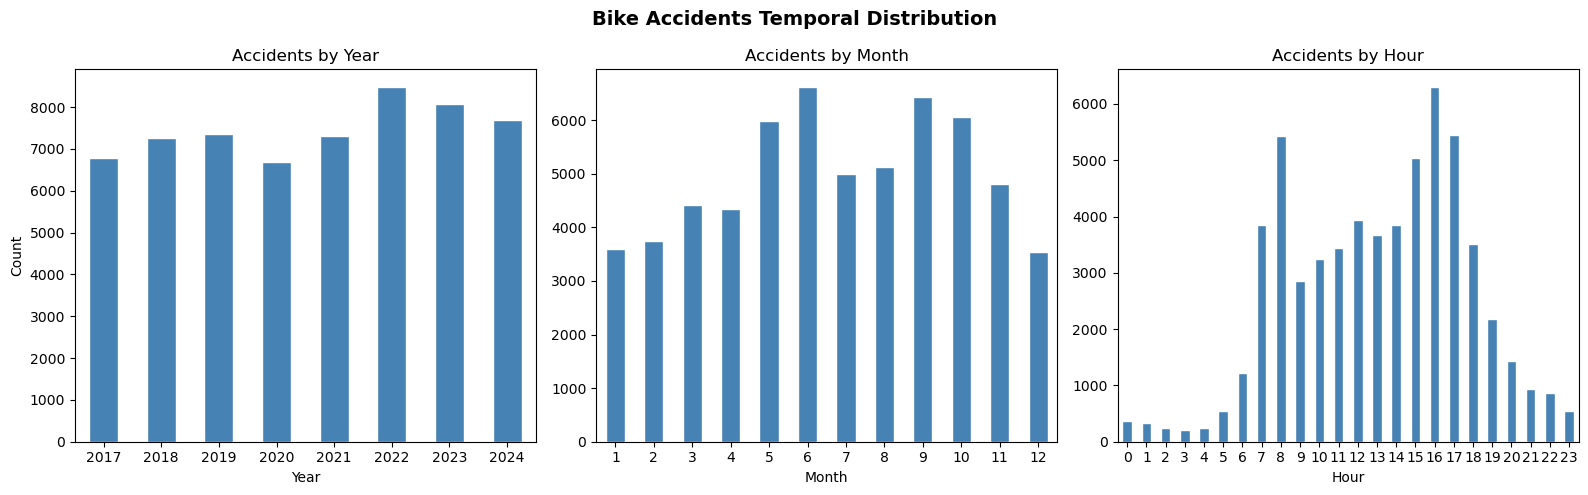

In [40]:
# ── TEMPORAL DISTRIBUTION ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By year
accidents_bikes["DT_YEAR_COLLISION"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Accidents by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# By month
accidents_bikes["DT_MONTH_COLLISION"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Accidents by Month")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis="x", rotation=0)

# By hour
accidents_bikes["DT_TIME"].value_counts().sort_index().plot(
    kind="bar", ax=axes[2], color="steelblue", edgecolor="white")
axes[2].set_title("Accidents by Hour")
axes[2].set_xlabel("Hour")
axes[2].tick_params(axis="x", rotation=0)

plt.suptitle("Bike Accidents Temporal Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [29]:
print(accidents_bikes.columns.tolist())

['DT_YEAR_COLLISION', 'DT_MONTH_COLLISION', 'DT_TIME', 'CD_NIS', 'TX_RGN_COLLISION_FR', 'TX_RGN_COLLISION_NL', 'TX_PROV_COLLISION_FR', 'TX_PROV_COLLISION_NL', 'TX_MUNTY_COLLISION_FR', 'TX_MUNTY_COLLISION_NL', 'MS_X_COORD', 'MS_Y_COORD', 'CD_CROSSWAY', 'TX_CROSSWAY_FR', 'TX_CROSSWAY_NL', 'CD_WEATHER', 'TX_WEATHER_FR', 'TX_WEATHER_NL', 'CD_ROAD_CONDITION', 'TX_ROAD_CONDITION_FR', 'TX_ROAD_CONDITION_NL', 'CD_BUILD_UP_AREA', 'TX_BUILD_UP_AREA_FR', 'TX_BUILD_UP_AREA_NL', 'CD_LIGHT_CONDITION', 'TX_LIGHT_CONDITION_FR', 'TX_LIGHT_CONDITION_NL', 'CD_ROAD_TYPE', 'CD_ROAD_TYPE_FR', 'CD_ROAD_TYPE_NL', 'CD_CLASS_ACCIDENTS', 'TX_CLASS_ACCIDENTS_FR', 'TX_CLASS_ACCIDENTS_NL', 'CD_ROAD_USR_TYPE1', 'TX_ROAD_USR_TYPE1_FR', 'TX_ROAD_USR_TYPE1_NL', 'CD_ROAD_USR_TYPE2', 'TX_ROAD_USR_TYPE2_FR', 'TX_ROAD_USR_TYPE2_NL', 'CD_COLLISION_TYPE', 'TX_COLLISON_TYPE_FR', 'TX_COLLISION_TYPE_NL', 'CD_OBSTACLES', 'TX_OBSTACLES_FR', 'TX_OBSTACLES_NL']


In [30]:
columns_to_keep = [
    # Time
    "DT_YEAR_COLLISION",
    "DT_MONTH_COLLISION",
    "DT_TIME",

    # Location
    "MS_X_COORD",
    "MS_Y_COORD",
    "TX_MUNTY_COLLISION_NL", # municipality

    # Road context
    "TX_CROSSWAY_NL", # intersection type
    "TX_ROAD_TYPE_NL", # road type
    "TX_BUILD_UP_AREA_NL", # urban vs rural

    # Conditions
    "TX_WEATHER_NL", # weather at accident
    "TX_ROAD_CONDITION_NL", # road condition
    "TX_LIGHT_CONDITION_NL", # light condition

    # Accident characteristics
    "TX_CLASS_ACCIDENTS_NL", # severity
    "TX_COLLISION_TYPE_NL", # collision type
    "TX_ROAD_USR_TYPE1_NL", # user type 1
    "TX_ROAD_USR_TYPE2_NL", # user type 2
    "TX_OBSTACLES_NL", # obstacles
]

In [31]:
#Analyisis
cat_columns = [
    "TX_CROSSWAY_NL",
    "TX_ROAD_CONDITION_NL",
    "TX_BUILD_UP_AREA_NL",
    "TX_WEATHER_NL",
    "TX_LIGHT_CONDITION_NL",
    "CD_ROAD_TYPE_NL",
    "TX_CLASS_ACCIDENTS_NL",
    "TX_COLLISION_TYPE_NL",
    "TX_ROAD_USR_TYPE1_NL",
    "TX_ROAD_USR_TYPE2_NL",
    "TX_OBSTACLES_NL"
]

for col in cat_columns:
    counts = accidents_bikes[col].value_counts()
    pct = (counts / len(accidents_bikes) * 100).round(1)
    summary = pd.DataFrame({"count": counts, "pct": pct})
    print(summary.to_string())

                  count   pct
TX_CROSSWAY_NL               
Buiten Kruispunt  33130  55.5
Op Kruispunt      26553  44.5
                                               count   pct
TX_ROAD_CONDITION_NL                                      
Droog                                          44176  74.0
Nat, plassen                                    7671  12.9
Onbekend                                        5120   8.6
Proper                                           926   1.6
Droog+Proper                                     885   1.5
Ijzel, sneeuw                                    405   0.7
Vuil (zand, grint, bladeren,...)                 373   0.6
Nat, plassen+Proper                               79   0.1
Nat, plassen+Vuil (zand, grint, bladeren,...)     27   0.0
Droog+Vuil (zand, grint, bladeren,...)            13   0.0
Ijzel, sneeuw+ roper                               5   0.0
Nat, plassen+Ijzel of sneeuw                       3   0.0
                     count   pct
TX_BUILD_UP_AREA_NL  

In [32]:
print(accidents_bikes[["DT_YEAR_COLLISION", "DT_MONTH_COLLISION", "DT_TIME"]].head(20))
print(accidents_bikes.columns.tolist())

      DT_YEAR_COLLISION  DT_MONTH_COLLISION  DT_TIME
1                  2017                   1        0
13                 2017                   1        7
200                2017                   1        7
1221               2017                   1       16
1222               2017                   1       15
1226               2017                   1       17
1230               2017                   1       16
1232               2017                   1       15
1233               2017                   1       15
1237               2017                   1       20
1238               2017                   1       13
1240               2017                   1       17
1242               2017                   1        8
1243               2017                   1       10
1250               2017                   1        9
1252               2017                   1       10
1253               2017                   1       15
1256               2017                   1   